In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib


In [2]:
df = pd.read_csv("../data/processed/high_value_churn_data.csv")

In [3]:
[col for col in df.columns if '_9' in col]

[]

In [4]:
X = df.drop("churn", axis=1)
y = df["churn"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [6]:
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)

In [7]:
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97      5484
           1       0.76      0.43      0.55       519

    accuracy                           0.94      6003
   macro avg       0.85      0.71      0.76      6003
weighted avg       0.93      0.94      0.93      6003

ROC-AUC: 0.9353602141243963


In [9]:

joblib.dump(rf, "../models/random_forest_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [10]:

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='importance',
    ascending=False
)

feature_importance.head(20)

,feature,importance
73,loc_ic_mou_8,0.045772
34,loc_og_mou_8,0.043373
91,total_ic_mou_8,0.038444
67,loc_ic_t2m_mou_8,0.037805
25,loc_og_t2m_mou_8,0.034810
64,loc_ic_t2t_mou_8,0.031213
7,arpu_8,0.030076
19,roam_og_mou_8,0.029769
61,total_og_mou_8,0.029658
22,loc_og_t2t_mou_8,0.026806


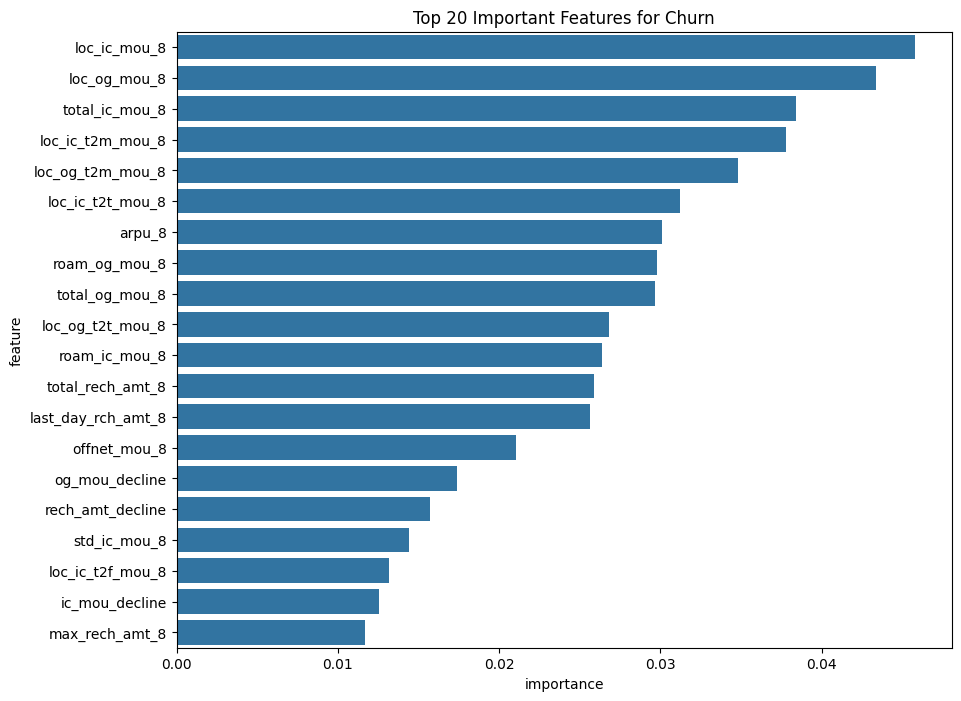

In [11]:

plt.figure(figsize=(10,8))
sns.barplot(
    x='importance',
    y='feature',
    data=feature_importance.head(20)
)
plt.title("Top 20 Important Features for Churn")
plt.show()

In [12]:
feature_importance.to_csv("../models/feature_importance.csv", index=False)